# Kinematic vs XGBoost vs TCN — LOAO cross-validation comparison

Leave-one-athlete-out CV for all three methods.  
Reports:
- F1 per class + macro (mean ± std across folds)
- Aggregate normalised confusion matrices
- Timing error per event type (ms and frames)

**Run `stage_xgb_tune.py` first** to get tuned XGBoost params.  
Falls back to default params if the results file is absent.

**TCN** metrics are loaded from the stage 4 LOAO JSON (set `TCN_LOAO_TRIAL_ID` below).  
Set to `None` to skip TCN in the comparison.

In [ ]:
import joblib
import json
import os


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from experiments.gait_detection.config import ExperimentConfig
from src.gait.detection.detectors import KinematicDetector
from src.gait.detection.metrics import (
    per_class_f1, timing_error_full, confusion_matrix,
)
from src.gait.detection.postprocess import (
    derive_events,
    min_duration_filter,
    majority_vote_filter,
    smooth_probs_argmax,
)
from src.gait.gait_data.dataset import load_dataset, train_test_split
from src.gait.image.dataset import load_image_dataset

xgb_params_path    = "data/output/gait/stage3/best_params.json"
IMG_XGB_MODEL_PATH = "data/output/gait/image/stage1/checkpoints/xgboost_best.pkl"


TCN_LOAO_TRIAL_ID = 78
TCN_LOAO_DIR      = "data/output/gait/stage4/results"


POSTPROCESSING = {
    "kinematic": {"method": "min_duration_filter",  "window": 3},
    "xgboost":   {"method": "smooth_probs_argmax",  "window": 3},
    "img_xgb":   {"method": "smooth_probs_argmax",  "window": 3},
    "tcn":       {"method": "smooth_probs_argmax",  "window": 3},
    "img_tcn":   {"method": "smooth_probs_argmax",  "window": 3},
}


def apply_pp(model_key: str, data: np.ndarray) -> np.ndarray:
    cfg_pp = POSTPROCESSING[model_key]
    method, window = cfg_pp["method"], cfg_pp["window"]
    if method == "min_duration_filter":
        return min_duration_filter(data, min_frames=window)
    if method == "majority_vote_filter":
        return majority_vote_filter(data, window=window)
    if method == "smooth_probs_argmax":
        return smooth_probs_argmax(data, window=window)
    raise ValueError(f"Unknown postprocessing method: {method!r}")

In [ ]:
cfg = ExperimentConfig()
all_records = load_dataset(cfg.annotations_csv, fps=cfg.fps)
train_records, test_records, TEST_ATHLETES = train_test_split(all_records)

athletes = sorted({r.athlete for r in train_records})
n_folds  = len(athletes)
print(f"{len(all_records)} total videos, {len(train_records)} train ({n_folds} athletes), "
      f"{len(test_records)} test")
print(f"Test athletes: {TEST_ATHLETES}")

# Image records use a different clipping window (starts at video frame 0 rather than
# the first YOLO-detected frame), so they must be loaded separately for correct
# label alignment when evaluating image TCN predictions.
IMG_FEATURES_DIR = "data/output/gait/image_features"
VIDEO_INPUT_DIR  = "data/input/optojump"

img_records_by_path = {}
if os.path.exists(IMG_FEATURES_DIR):
    img_all = load_image_dataset(cfg.annotations_csv, IMG_FEATURES_DIR, VIDEO_INPUT_DIR)
    img_records_by_path = {r.video_path: r for r in img_all}
    print(f"{len(img_all)} image records loaded")
else:
    print(f"Image features not found ({IMG_FEATURES_DIR}) — image TCN evaluation will be skipped.")

In [3]:
with open(xgb_params_path) as f:
    xgb_meta = json.load(f)
XGB_PARAMS = xgb_meta["best_params"]
print(f"Loaded tuned params  (val macro F1 = {xgb_meta['best_val_macro_f1']:.3f})")
print(f"feature_idx from tuning: {xgb_meta['feature_idx']}")


Loaded tuned params  (val macro F1 = 0.854)
feature_idx from tuning: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [4]:
EVENT_KEYS = ["left_landing", "left_takeoff", "right_landing", "right_takeoff"]


def flatten(records, feature_idx=None):
    X, y = [], []
    for r in records:
        feats = r.features if feature_idx is None else r.features[:, feature_idx]
        X.append(feats)
        y.append(r.labels)
    return np.vstack(X), np.concatenate(y)


def eval_fold(preds_per_rec, val_records, cfg):
    """Compute all metrics for one fold given a list of per-record prediction arrays."""
    all_true, all_pred = [], []
    timing = {k: [] for k in EVENT_KEYS}

    for rec, pred in zip(val_records, preds_per_rec):
        all_true.append(rec.labels)
        all_pred.append(pred)
        gt_ev   = derive_events(rec.labels, cfg.fps)
        pred_ev = derive_events(pred,        cfg.fps)
        for key in EVENT_KEYS:
            timing[key].append(timing_error_full(pred_ev[key], gt_ev[key], cfg.fps))

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    def _mean(lst, unit):
        vals = [d[unit] for d in lst if not np.isnan(d[unit])]
        return float(np.mean(vals)) if vals else float("nan")

    return {
        "f1":             per_class_f1(y_true, y_pred, cfg.n_classes, cfg.class_names),
        "confusion_matrix": confusion_matrix(y_true, y_pred, cfg.n_classes),
        "timing_error":   {k: {"ms":     _mean(timing[k], "ms"),
                               "frames": _mean(timing[k], "frames")}
                           for k in EVENT_KEYS},
    }

In [5]:
# ── Train XGBoost on all train_records ───────────────────────────────────────
XGB_NEEDS_PROBA = POSTPROCESSING["xgboost"]["method"] == "smooth_probs_argmax"

X_all_train, y_all_train = flatten(train_records, cfg.feature_idx)
clf_final = xgb.XGBClassifier(
    **XGB_PARAMS,
    eval_metric="mlogloss", tree_method="hist", device="cpu", verbosity=0,
)
clf_final.fit(X_all_train, y_all_train)

# ── Evaluate on train set (in-sample) ────────────────────────────────────────
kinematic = KinematicDetector()

kin_train_preds = [apply_pp("kinematic", kinematic.predict(r.features, cfg.fps))
                   for r in train_records]
kin_train = eval_fold(kin_train_preds, train_records, cfg)

xgb_train_preds = []
for r in train_records:
    feats = r.features if cfg.feature_idx is None else r.features[:, cfg.feature_idx]
    if XGB_NEEDS_PROBA:
        xgb_train_preds.append(apply_pp("xgboost", clf_final.predict_proba(feats)))
    else:
        xgb_train_preds.append(apply_pp("xgboost", clf_final.predict(feats).astype(np.int64)))
xgb_train = eval_fold(xgb_train_preds, train_records, cfg)

In [ ]:
img_xgb_clf          = None
img_xgb_train_result = None

if os.path.exists(IMG_XGB_MODEL_PATH) and img_records_by_path:
    img_xgb_clf = joblib.load(IMG_XGB_MODEL_PATH)

    img_xgb_tr_preds, img_xgb_tr_recs = [], []
    for r in train_records:
        img_rec = img_records_by_path.get(r.video_path)
        if img_rec is None:
            continue
        img_xgb_tr_preds.append(apply_pp("img_xgb", img_xgb_clf.predict_proba(img_rec.features)))
        img_xgb_tr_recs.append(img_rec)

    if img_xgb_tr_preds:
        img_xgb_train_result = eval_fold(img_xgb_tr_preds, img_xgb_tr_recs, cfg)
        print(f"Image XGBoost train macro F1: {img_xgb_train_result['f1']['macro']:.3f}  "
              f"({len(img_xgb_tr_recs)}/{len(train_records)} records)")
else:
    print(f"Image XGBoost model not found ({IMG_XGB_MODEL_PATH}) — run img_baselines to add to comparison.")

In [ ]:
classes_all = cfg.class_names + ["macro"]

# ── postprocessing label helpers ──────────────────────────────────────────────
def _pp_label(key):
    pp = POSTPROCESSING[key]
    name = pp["method"].replace("_filter", "").replace("_argmax", "")
    return f"{name}  w={pp['window']}"

def _result_f1(result):
    return {c: [result["f1"][c]] for c in classes_all}

def _result_timing(result, unit):
    return {k: [result["timing_error"][k][unit]] for k in EVENT_KEYS}

# ── Pose TCN train-set results from inference manifest ────────────────────────
TCN_MANIFEST     = "data/output/gait/stage6/manifest.json"
IMG_TCN_MANIFEST = "data/output/gait/image/stage6/manifest.json"

TCN_NEEDS_PROBA     = POSTPROCESSING["tcn"]["method"]     == "smooth_probs_argmax"
IMG_TCN_NEEDS_PROBA = POSTPROCESSING["img_tcn"]["method"] == "smooth_probs_argmax"

tcn_train_result     = None
img_tcn_train_result = None
manifest             = None
img_manifest         = None
manifest_idx         = {}
img_manifest_idx     = {}

if os.path.exists(TCN_MANIFEST):
    with open(TCN_MANIFEST) as f:
        manifest = json.load(f)
    manifest_idx = {r["video_path"]: r for r in manifest["records"]}

    tcn_tr_preds, tcn_tr_recs = [], []
    for rec in train_records:
        entry = manifest_idx.get(rec.video_path)
        if entry is None or entry["split"] != "train":
            continue
        probs = np.load(entry["probs_path"])
        pred  = apply_pp("tcn", probs) if TCN_NEEDS_PROBA \
                else apply_pp("tcn", probs.argmax(axis=1).astype(np.int64))
        tcn_tr_preds.append(pred)
        tcn_tr_recs.append(rec)

    if tcn_tr_preds:
        tcn_train_result = eval_fold(tcn_tr_preds, tcn_tr_recs, cfg)
        print(f"Pose TCN train macro F1: {tcn_train_result['f1']['macro']:.3f}  "
              f"({len(tcn_tr_recs)}/{len(train_records)} records from manifest)")
else:
    print(f"Pose TCN manifest not found ({TCN_MANIFEST}) — run stage6_infer to add to comparison.")

if os.path.exists(IMG_TCN_MANIFEST):
    with open(IMG_TCN_MANIFEST) as f:
        img_manifest = json.load(f)
    img_manifest_idx = {r["video_path"]: r for r in img_manifest["records"]}

    img_tr_preds, img_tr_recs = [], []
    for rec in train_records:
        entry = img_manifest_idx.get(rec.video_path)
        if entry is None or entry["split"] != "train":
            continue
        img_rec = img_records_by_path.get(rec.video_path)
        if img_rec is None:
            continue
        probs = np.load(entry["probs_path"])
        pred  = apply_pp("img_tcn", probs) if IMG_TCN_NEEDS_PROBA \
                else apply_pp("img_tcn", probs.argmax(axis=1).astype(np.int64))
        img_tr_preds.append(pred)
        img_tr_recs.append(img_rec)

    if img_tr_preds:
        img_tcn_train_result = eval_fold(img_tr_preds, img_tr_recs, cfg)
        print(f"Image TCN train macro F1: {img_tcn_train_result['f1']['macro']:.3f}  "
              f"({len(img_tr_recs)}/{len(train_records)} records from manifest)")
else:
    print(f"Image TCN manifest not found ({IMG_TCN_MANIFEST}) — run img_tcn_infer to add to comparison.")

# ── method registries ─────────────────────────────────────────────────────────
METHODS_TRAIN = [
    {"label": f"Kinematic  [{_pp_label('kinematic')}]", "color": "#4e79a7",
     "f1": _result_f1(kin_train), "timing_ms": _result_timing(kin_train, "ms"),
     "timing_fr": _result_timing(kin_train, "frames"), "cm": kin_train["confusion_matrix"]},
    {"label": f"XGBoost  [{_pp_label('xgboost')}]", "color": "#f28e2b",
     "f1": _result_f1(xgb_train), "timing_ms": _result_timing(xgb_train, "ms"),
     "timing_fr": _result_timing(xgb_train, "frames"), "cm": xgb_train["confusion_matrix"]},
]
if img_xgb_train_result is not None:
    METHODS_TRAIN.append({
        "label": f"Image XGBoost  [{_pp_label('img_xgb')}]", "color": "#d4a0c7",
        "f1": _result_f1(img_xgb_train_result), "timing_ms": _result_timing(img_xgb_train_result, "ms"),
        "timing_fr": _result_timing(img_xgb_train_result, "frames"), "cm": img_xgb_train_result["confusion_matrix"],
    })
if tcn_train_result is not None:
    METHODS_TRAIN.append({
        "label": f"Pose TCN (trial #{manifest['trial_id']})  [{_pp_label('tcn')}]", "color": "#59a14f",
        "f1": _result_f1(tcn_train_result), "timing_ms": _result_timing(tcn_train_result, "ms"),
        "timing_fr": _result_timing(tcn_train_result, "frames"), "cm": tcn_train_result["confusion_matrix"],
    })
if img_tcn_train_result is not None:
    METHODS_TRAIN.append({
        "label": f"Image TCN (trial #{img_manifest['trial_id']})  [{_pp_label('img_tcn')}]", "color": "#b07aa1",
        "f1": _result_f1(img_tcn_train_result), "timing_ms": _result_timing(img_tcn_train_result, "ms"),
        "timing_fr": _result_timing(img_tcn_train_result, "frames"), "cm": img_tcn_train_result["confusion_matrix"],
    })

# ── test-set evaluation ───────────────────────────────────────────────────────
kin_test_preds = [apply_pp("kinematic", kinematic.predict(r.features, cfg.fps)) for r in test_records]
kin_test = eval_fold(kin_test_preds, test_records, cfg)

xgb_test_preds = []
for r in test_records:
    feats = r.features if cfg.feature_idx is None else r.features[:, cfg.feature_idx]
    if XGB_NEEDS_PROBA:
        xgb_test_preds.append(apply_pp("xgboost", clf_final.predict_proba(feats)))
    else:
        xgb_test_preds.append(apply_pp("xgboost", clf_final.predict(feats).astype(np.int64)))
xgb_test = eval_fold(xgb_test_preds, test_records, cfg)

METHODS_TEST = [
    {"label": f"Kinematic  [{_pp_label('kinematic')}]", "color": "#4e79a7",
     "f1": _result_f1(kin_test), "timing_ms": _result_timing(kin_test, "ms"),
     "timing_fr": _result_timing(kin_test, "frames"), "cm": kin_test["confusion_matrix"]},
    {"label": f"XGBoost  [{_pp_label('xgboost')}]", "color": "#f28e2b",
     "f1": _result_f1(xgb_test), "timing_ms": _result_timing(xgb_test, "ms"),
     "timing_fr": _result_timing(xgb_test, "frames"), "cm": xgb_test["confusion_matrix"]},
]

if img_xgb_clf is not None:
    img_xgb_test_preds, img_xgb_test_recs = [], []
    for r in test_records:
        img_rec = img_records_by_path.get(r.video_path)
        if img_rec is None:
            continue
        img_xgb_test_preds.append(apply_pp("img_xgb", img_xgb_clf.predict_proba(img_rec.features)))
        img_xgb_test_recs.append(img_rec)
    if img_xgb_test_preds:
        img_xgb_test = eval_fold(img_xgb_test_preds, img_xgb_test_recs, cfg)
        METHODS_TEST.append({
            "label": f"Image XGBoost  [{_pp_label('img_xgb')}]", "color": "#d4a0c7",
            "f1": _result_f1(img_xgb_test), "timing_ms": _result_timing(img_xgb_test, "ms"),
            "timing_fr": _result_timing(img_xgb_test, "frames"), "cm": img_xgb_test["confusion_matrix"],
        })

print(f"Train set: {len(train_records)} videos")
print(f"Test  set: {len(test_records)} videos ({TEST_ATHLETES})")

---
## Train set — in-sample evaluation

In [7]:
def plot_f1_bars(methods, title, ax=None):
    n_methods = len(methods)
    w = 0.7 / n_methods
    x = np.arange(len(classes_all))
    fig, ax = plt.subplots(figsize=(11, 5)) if ax is None else (None, ax)
    for i, m in enumerate(methods):
        means = [np.nanmean(m["f1"][c]) for c in classes_all]
        stds  = [np.nanstd(m["f1"][c])  for c in classes_all]
        offset = (i - n_methods / 2 + 0.5) * w
        bars = ax.bar(x + offset, means, w, yerr=stds, capsize=4,
                      label=m["label"], color=m["color"], alpha=0.9)
        for bar, val in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace("_", "\n") for c in classes_all], fontsize=10)
    ax.set_ylabel("F1 score")
    ax.set_ylim(0, 1.15)
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    if fig:
        plt.tight_layout()
        plt.show()

## Confusion matrices

In [8]:
def plot_confusion_matrices(methods, suptitle):
    labels_short = ["L-stance", "R-stance", "Flight"]
    n = len(methods)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, m in zip(axes, methods):
        cm_arr  = np.array(m["cm"], dtype=float)
        cm_norm = cm_arr / cm_arr.sum(axis=1, keepdims=True)
        sns.heatmap(cm_norm, annot=True, fmt=".2f", ax=ax,
                    xticklabels=labels_short, yticklabels=labels_short,
                    cmap="Blues", vmin=0, vmax=1, cbar=False)
        ax.set_title(f"{m['label']}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
    plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

## Timing errors

In [9]:
def plot_timing(methods, title_suffix):
    event_labels = [k.replace("_", "\n") for k in EVENT_KEYS]
    x = np.arange(len(EVENT_KEYS))
    n_methods = len(methods)
    w = 0.7 / n_methods
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, unit, ylabel in zip(axes, ["timing_ms", "timing_fr"], ["MAE (ms)", "MAE (frames)"]):
        for i, m in enumerate(methods):
            means = [np.nanmean(m[unit][k]) for k in EVENT_KEYS]
            stds  = [np.nanstd(m[unit][k])  for k in EVENT_KEYS]
            offset = (i - n_methods / 2 + 0.5) * w
            ax.bar(x + offset, means, w, yerr=stds, capsize=4,
                   label=m["label"], color=m["color"], alpha=0.9)
        ax.set_xticks(x)
        ax.set_xticklabels(event_labels)
        ax.set_ylabel(ylabel)
        ax.set_title(f"Timing error — {ylabel}  {title_suffix}")
        ax.legend()
        ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [10]:
def timing_table(methods):
    rows = []
    for k in EVENT_KEYS:
        row = {"Event": k.replace("_", " ")}
        for m in methods:
            ms_vals = [v for v in m["timing_ms"][k] if not np.isnan(v)]
            fr_vals = [v for v in m["timing_fr"][k] if not np.isnan(v)]
            lbl = m["label"]
            row[f"{lbl} (ms)"]     = f"{np.mean(ms_vals):.1f} ± {np.std(ms_vals):.1f}" if ms_vals else "—"
            row[f"{lbl} (frames)"] = f"{np.mean(fr_vals):.1f} ± {np.std(fr_vals):.1f}" if fr_vals else "—"
        rows.append(row)
    return pd.DataFrame(rows).set_index("Event")

In [11]:
def f1_table(methods):
    rows = []
    for c in classes_all:
        row = {"Class": c.replace("_", " ")}
        for m in methods:
            mean = np.nanmean(m["f1"][c])
            std  = np.nanstd(m["f1"][c])
            row[f"{m['label']} F1"] = f"{mean:.3f} ± {std:.3f}"
        row[f"Δ (last − first)"] = (
            f"{np.nanmean(methods[-1]['f1'][c]) - np.nanmean(methods[0]['f1'][c]):+.3f}"
        )
        rows.append(row)
    return pd.DataFrame(rows).set_index("Class")


---
## Test set — held-out athletes

TCN and XGBoost are evaluated with the model trained on all train athletes.

In [ ]:
tcn_test_preds = []
tcn_test_recs  = []
for rec in test_records:
    entry = manifest_idx.get(rec.video_path)
    if entry is None or entry["split"] != "test":
        continue
    probs = np.load(entry["probs_path"])
    pred  = apply_pp("tcn", probs) if TCN_NEEDS_PROBA \
            else apply_pp("tcn", probs.argmax(axis=1).astype(np.int64))
    tcn_test_preds.append(pred)
    tcn_test_recs.append(rec)

if tcn_test_preds:
    tcn_test = eval_fold(tcn_test_preds, tcn_test_recs, cfg)
    METHODS_TEST.append({
        "label": f"Pose TCN (trial #{manifest['trial_id']})  [{_pp_label('tcn')}]",
        "color": "#59a14f",
        "f1":        _result_f1(tcn_test),
        "timing_ms": _result_timing(tcn_test, "ms"),
        "timing_fr": _result_timing(tcn_test, "frames"),
        "cm":        tcn_test["confusion_matrix"],
    })
    print(f"Pose TCN test macro F1: {tcn_test['f1']['macro']:.3f}")
else:
    print("No pose TCN test records found in manifest.")

img_tcn_test_preds = []
img_tcn_test_recs  = []
for rec in test_records:
    entry = img_manifest_idx.get(rec.video_path)
    if entry is None or entry["split"] != "test":
        continue
    img_rec = img_records_by_path.get(rec.video_path)
    if img_rec is None:
        continue
    probs = np.load(entry["probs_path"])
    pred  = apply_pp("img_tcn", probs) if IMG_TCN_NEEDS_PROBA \
            else apply_pp("img_tcn", probs.argmax(axis=1).astype(np.int64))
    img_tcn_test_preds.append(pred)
    img_tcn_test_recs.append(img_rec)

if img_tcn_test_preds:
    img_tcn_test = eval_fold(img_tcn_test_preds, img_tcn_test_recs, cfg)
    METHODS_TEST.append({
        "label": f"Image TCN (trial #{img_manifest['trial_id']})  [{_pp_label('img_tcn')}]",
        "color": "#b07aa1",
        "f1":        _result_f1(img_tcn_test),
        "timing_ms": _result_timing(img_tcn_test, "ms"),
        "timing_fr": _result_timing(img_tcn_test, "frames"),
        "cm":        img_tcn_test["confusion_matrix"],
    })
    print(f"Image TCN test macro F1: {img_tcn_test['f1']['macro']:.3f}")
else:
    print("No image TCN test records found in manifest.")

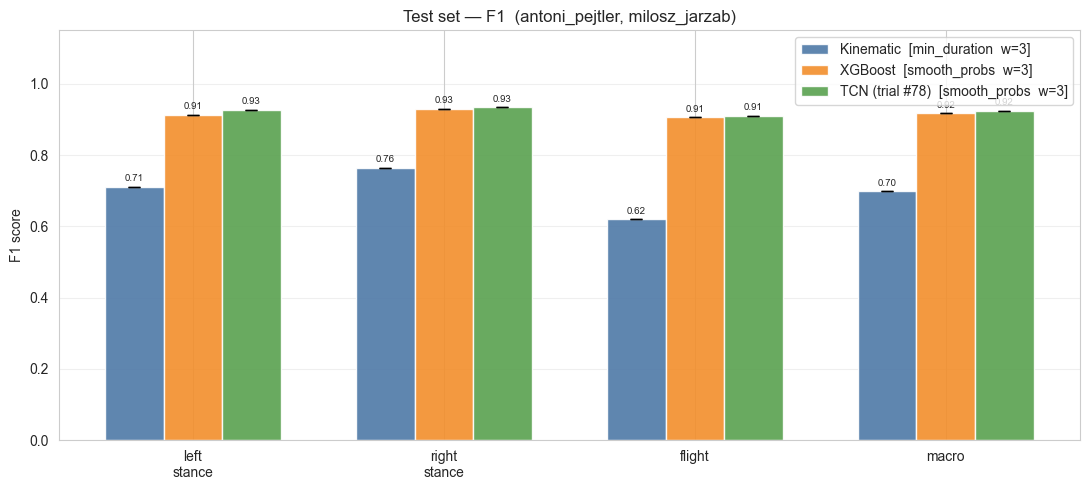

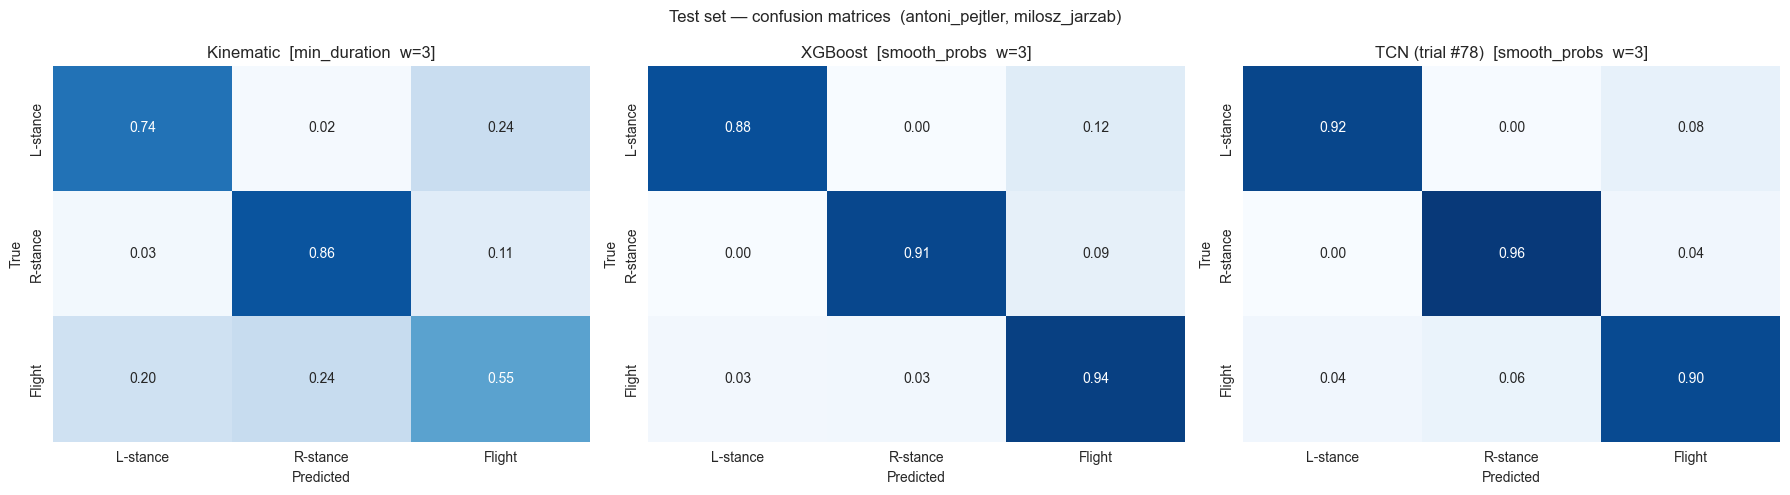

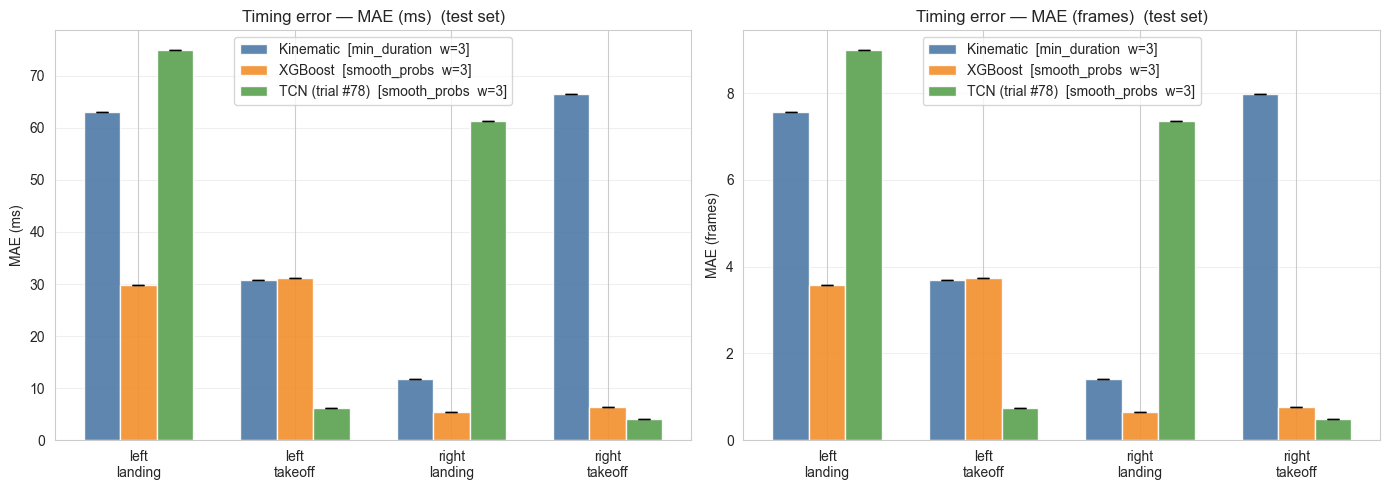

In [13]:
plot_f1_bars(METHODS_TEST, f"Test set — F1  ({', '.join(TEST_ATHLETES)})")
plot_confusion_matrices(METHODS_TEST, f"Test set — confusion matrices  ({', '.join(TEST_ATHLETES)})")
plot_timing(METHODS_TEST, f"(test set)")
print()
